<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Ordinal_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encoding Categorical Variables


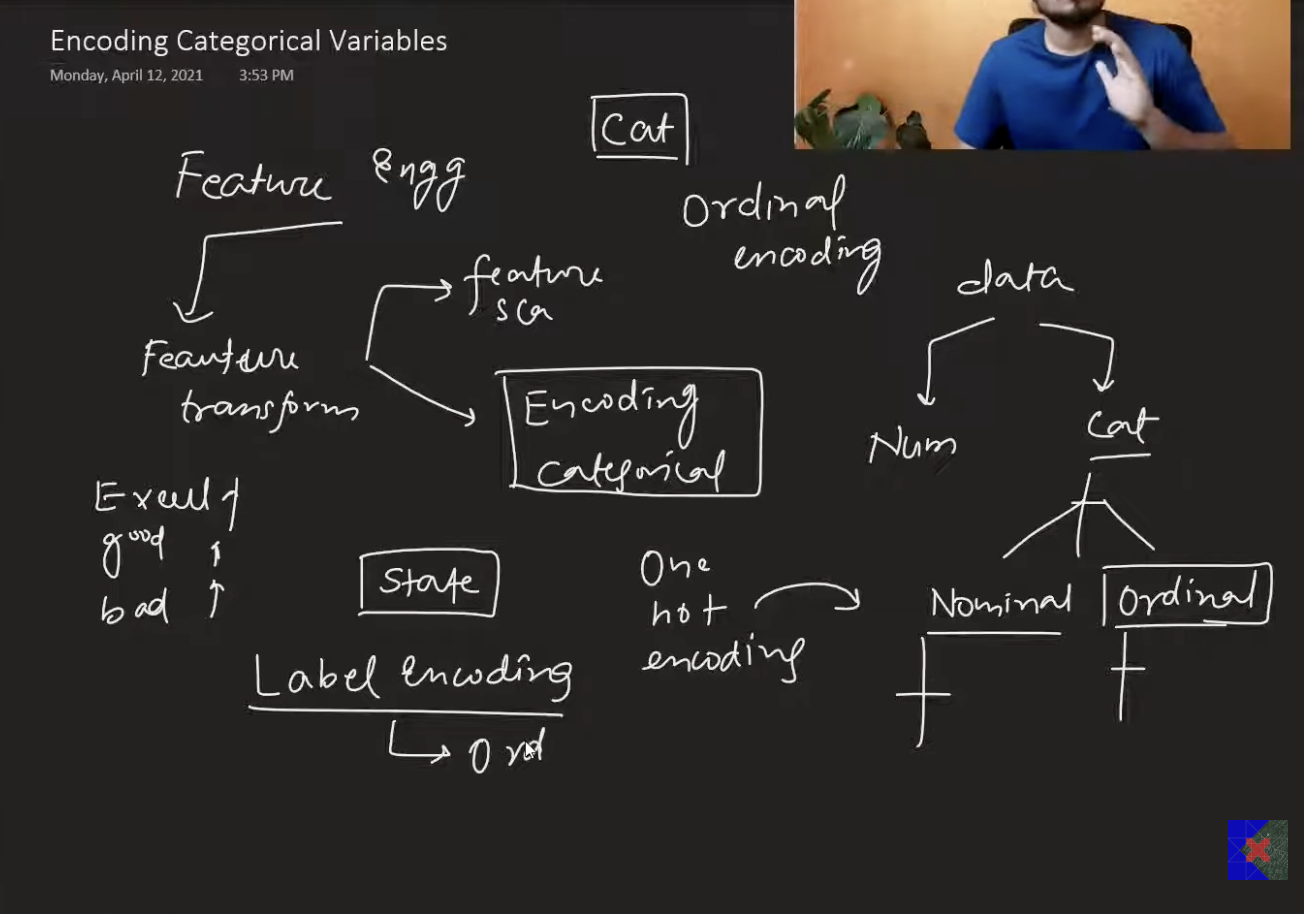

Data:

Numerical : Numbers

Categorical : Strings

Nominal -> Categroies no relation or order in betweeen eg: State

Ordinal -> Categroies has relation or order in betweeen eg: Marks, Class

Convert String of Categorical Data to numbers

To convert there are lot of techniques -

1. Ordinal Encoding : Ordinal
2. One Hot Encoding : Nominal
3. Label Encoding : Same as Ordinal Encoding

Ordinal: data -> input X and output y
if X has ordinal data -> apply OE
if also y is categorical -> Not OE we use label encoding

Data has column called Education:

HS

UG

PG

PG

UG

HS

UG


PG > UG > HS -> Order is there



In [34]:
import numpy as np
import pandas as pd

In [35]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day26-ordinal-encoding/customer.csv')

In [36]:
df.sample(5)

,age,gender,review,education,purchased
18,19,Male,Good,School,No
48,39,Female,Good,UG,Yes
8,65,Female,Average,UG,No
21,32,Male,Average,PG,No
0,30,Female,Average,School,No


In [37]:
df = df.iloc[:,2:]

In [38]:
df.head()

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No


In [39]:
# in any feature transformation first do train test split

In [59]:
df

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No
5,Average,School,Yes
6,Good,School,No
7,Poor,School,Yes
8,Average,UG,No
9,Good,UG,Yes


In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:2],df.iloc[:,-1], test_size=0.2)

In [42]:
X_train.head(5)

,review,education
13,Average,School
11,Good,UG
16,Poor,UG
29,Average,UG
0,Average,School


In [43]:
from sklearn.preprocessing import OrdinalEncoder

In [44]:
# create object of Ordinal Encoder and pass parameter called categories, list of list
oe = OrdinalEncoder(categories=[['Poor', 'Average', 'Good'],['School','UG', 'PG']])

In [45]:
oe.fit(X_train) # Look at the training data and learn the mapping.

OrdinalEncoder(categories=[['Poor', 'Average', 'Good'], ['School', 'UG', 'PG']])

In [46]:
# Use the learned dictionary to convert actual values.
X_train = oe.transform(X_train)
X_test = oe.transform(X_test)

In [47]:
X_train

array([[1., 0.],
       [2., 1.],
       [0., 1.],
       [1., 1.],
       [1., 0.],
       [0., 2.],
       [2., 1.],
       [2., 0.],
       [1., 1.],
       [2., 0.],
       [0., 2.],
       [2., 2.],
       [2., 2.],
       [1., 0.],
       [2., 1.],
       [2., 1.],
       [0., 1.],
       [1., 2.],
       [0., 2.],
       [0., 1.],
       [2., 0.],
       [0., 2.],
       [1., 1.],
       [0., 2.],
       [0., 2.],
       [0., 0.],
       [1., 0.],
       [1., 1.],
       [2., 2.],
       [1., 2.],
       [2., 0.],
       [2., 2.],
       [2., 0.],
       [0., 2.],
       [2., 1.],
       [1., 2.],
       [0., 2.],
       [1., 0.],
       [1., 1.],
       [0., 0.]])

In [48]:
oe.categories_

[array(['Poor', 'Average', 'Good'], dtype=object),
 array(['School', 'UG', 'PG'], dtype=object)]

In [49]:
# Label Encoding for output column i.e y

In [51]:
from sklearn.preprocessing import LabelEncoder

In [52]:
le = LabelEncoder()

In [54]:
le.fit(y_train)

LabelEncoder()

In [55]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [56]:
y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [57]:
y_train

array([0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0])